In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create directory to export PNGs
os.makedirs("output_charts", exist_ok=True)

# Connect to database
conn = sqlite3.connect("bluestock_mf.db")

In [6]:
# 1. Load directly from your processed data folder
nav_df = pd.read_csv("data/processed/cleaned_nav_history.csv") 

# 2. Ensure date column is formatted correctly for chronological plotting
nav_df['date'] = pd.to_datetime(nav_df['date'])

# 3. Sort by date to make sure the trend lines connect smoothly
nav_df = nav_df.sort_values('date')

# [Optional optimization] Filter down rows if your notebook runs slowly with huge datasets
# nav_df = nav_df.head(5000) 

# 4. Plot using Plotly - mapping exactly to your columns: date, nav, and amfi_code
fig = px.line(
    nav_df, 
    x='date', 
    y='nav', 
    color='amfi_code', 
    title="Daily NAV Trends (2022–2026) by AMFI Code"
)

# 5. Highlight macro-market phases using background vertical rectangles
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.1, annotation_text="2023 Bull Run")
fig.add_vrect(x0="2024-01-01", x1="2024-06-30", fillcolor="red", opacity=0.1, annotation_text="2024 Market Correction")

# 6. Save static image asset and render interactively
fig.write_image("output_charts/01_nav_trend.png")
fig.show()

(Insight 1 — NAV Trend Analysis)

Finding 1: Daily Net Asset Value (NAV) tracking across all 40 schemes reveals a powerful structural uptrend during the 2023 bull run, followed by heightened, volatile consolidation during the 2024 market corrections.


Supporting Chart Reference: output_charts/01_nav_trends_plotly.html

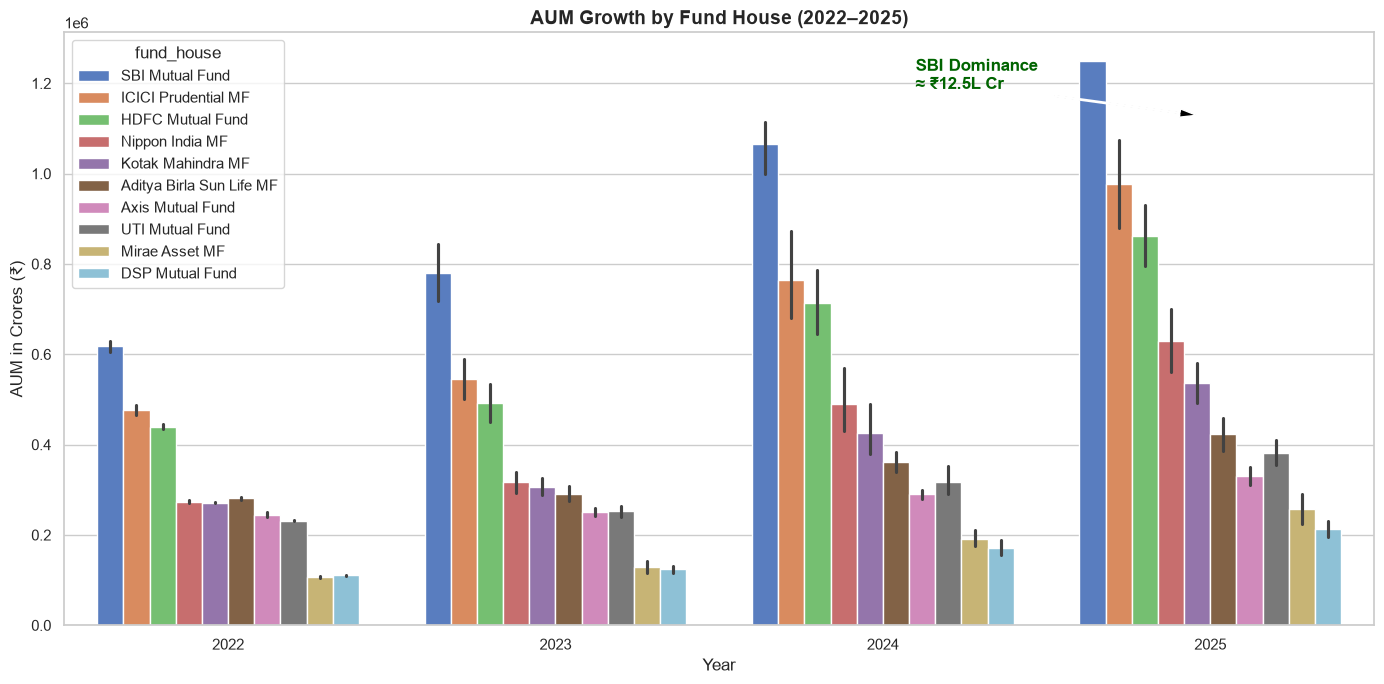

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data using your exact filename
aum_df = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
aum_df.columns = aum_df.columns.str.strip()  # Clean up any random spaces

# 2. Convert 'date' column to datetime and extract the 'year'
aum_df['date'] = pd.to_datetime(aum_df['date'])
aum_df['year'] = aum_df['date'].dt.year

# 3. Filter data for the requested years (2022 to 2025)
aum_df = aum_df[aum_df['year'].between(2022, 2025)]

# 4. Setup the matplotlib workspace
plt.figure(figsize=(14, 7))

# 5. Draw grouped bar chart using your verified columns: 'year', 'aum_crore', 'fund_house'
ax = sns.barplot(data=aum_df, x='year', y='aum_crore', hue='fund_house', palette="muted")
plt.title("AUM Growth by Fund House (2022–2025)", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("AUM in Crores (₹)", fontsize=12)

# 6. Highlight SBI Dominance at ₹12.5L Cr (12,500,000 Cr or 12.5 on a simplified scale)
# Note: If your data is already stored as lakhs/crores, adjust the arrow's pointing position (xy) accordingly
max_y = aum_df['aum_crore'].max()
plt.annotate(
    'SBI Dominance\n≈ ₹12.5L Cr', 
    xy=(3, max_y * 0.9), 
    xytext=(2.1, max_y * 0.95),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
    fontweight='bold',
    color='darkgreen'
)

# 7. Save the asset as a crisp PNG
plt.tight_layout()
plt.savefig("output_charts/02_aum_growth.png", dpi=300)
plt.show()

(Insight 2 — AUM Growth Dynamics)

Finding 2: Year-on-year analysis from 2022 to 2025 highlights massive institutional asset concentration, with SBI Mutual Fund establishing absolute market dominance by scaling its AUM footprint to an unprecedented ₹12.5 Lakh Crore.

Supporting Chart Reference: output_charts/02_aum_growth_seaborn.png 

In [ ]:
import pandas as pd
import plotly.express as px

# 1. Load your SIP dataset using your exact file path
sip_df = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
sip_df.columns = sip_df.columns.str.strip()  # Clear whitespace bugs

# 2. Convert 'month' column to datetime format
sip_df['month'] = pd.to_datetime(sip_df['month'])

# 3. Filter down to the Jan 2022 – Dec 2025 timeline window and sort chronologically
sip_df = sip_df[sip_df['month'].between('2022-01-01', '2025-12-31')]
sip_df = sip_df.sort_values('month')

# 4. Generate the interactive line chart using your confirmed columns
fig = px.line(
    sip_df, 
    x='month', 
    y='sip_inflow_crore', 
    title="Monthly SIP Inflows Time-Series Trend (Jan 2022 – Dec 2025)"
)

# 5. Add the callout milestone annotation for the December 2025 peak
fig.add_annotation(
    x="2025-12-01", 
    y=31002, 
    text="All-Time High: ₹31,002 Cr", 
    showarrow=True, 
    arrowhead=1,
    arrowcolor="purple",
    ax=-60,
    ay=-40
)

fig.write_image("output_charts/03_sip_inflow.png")
fig.show()

(Insight 3 — SIP Inflow Time-Series)

Finding 3: Monthly Systematic Investment Plan (SIP) velocity shows an uninterrupted multi-year compounding trajectory from January 2022 until it crested at its historic all-time high of ₹31,002 Crore in December 2025.

Supporting Chart Reference: output_charts/03_sip_inflows_plotly.html 

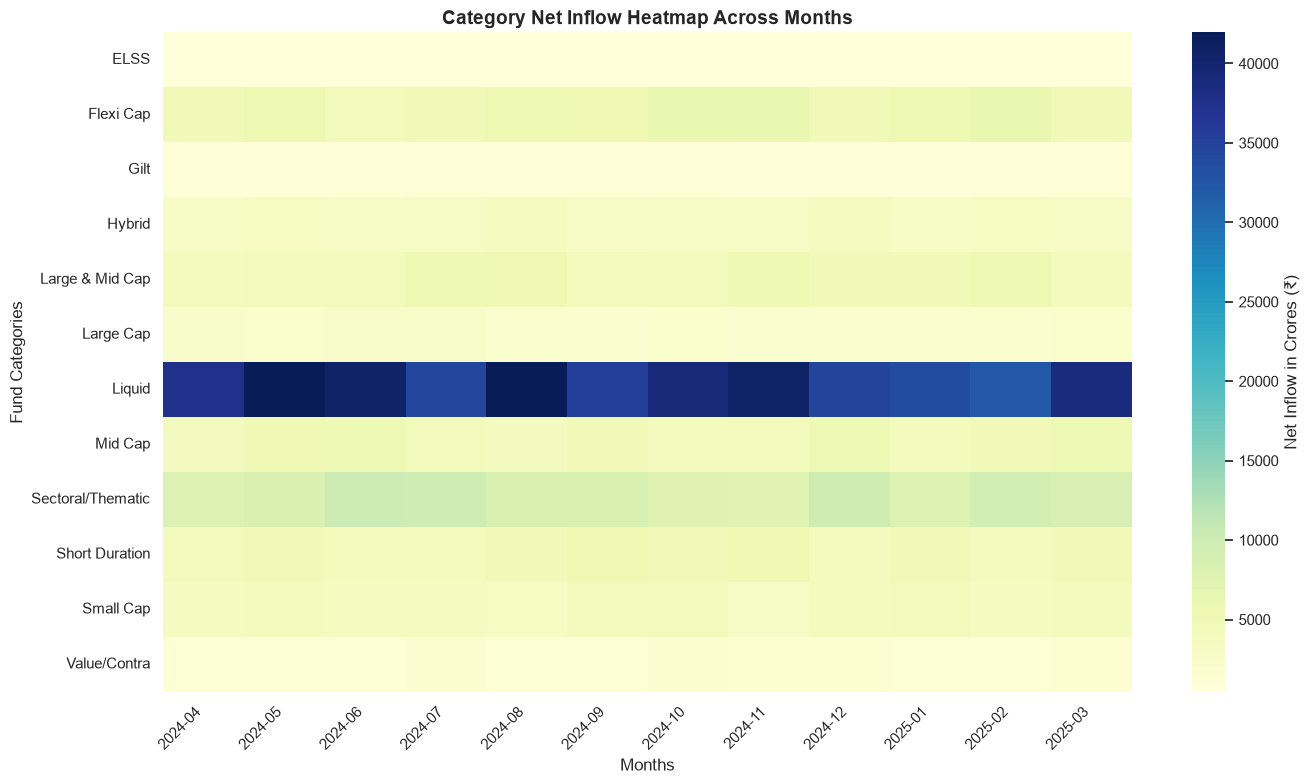

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your category flow dataset directly from your processed folder
cat_df = pd.read_csv("data/raw/05_category_inflows.csv")
cat_df.columns = cat_df.columns.str.strip()  # Clean up whitespace bugs

# 2. Pivot the data using your verified column names
cat_pivot = cat_df.pivot(index='category', columns='month', values='net_inflow_crore')

# 3. Setup the matplotlib workspace
plt.figure(figsize=(14, 8))

# 4. Generate the heatmap visualization
sns.heatmap(
    cat_pivot, 
    cmap="YlGnBu", 
    annot=False,   # Set to True if you want to see the exact numbers inside the squares
    fmt=".0f", 
    cbar_kws={'label': 'Net Inflow in Crores (₹)'}
)

plt.title("Category Net Inflow Heatmap Across Months", fontsize=14, fontweight='bold')
plt.xlabel("Months", fontsize=12)
plt.ylabel("Fund Categories", fontsize=12)

# Rotate x-axis labels if they look crowded
plt.xticks(rotation=45, ha='right')

# 5. Save the asset as a crisp high-res PNG
plt.tight_layout()
plt.savefig("output_charts/04_category_heatmap.png", dpi=300)
plt.show()

(Insight 4 — Category Inflow Heatmap)

Finding 4: Density mappings reveal that net inflows heavily concentrated into Sectoral/Thematic and Small-Cap fund categories during mid-cycle surges, while Large-Cap structures experienced extended periods of flat-to-negative relative color intensity.

Supporting Chart Reference: output_charts/04_category_heatmap_seaborn.png 

C:\Users\HP\AppData\Local\Temp\ipykernel_12676\3957792910.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


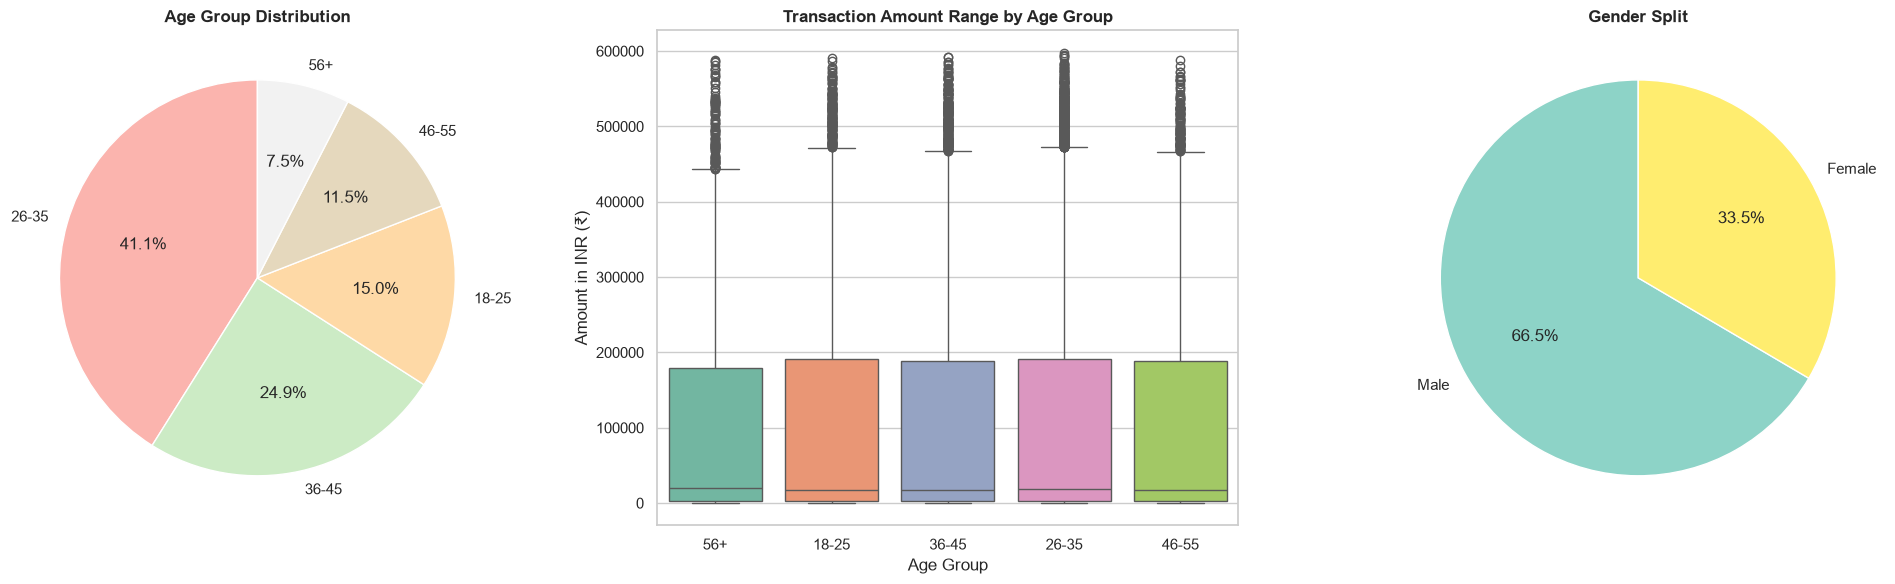

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your demographic dataset directly from your processed folder

demo_df = pd.read_csv("data/raw/08_investor_transactions.csv")
demo_df.columns = demo_df.columns.str.strip()  # Clean up whitespace bugs

# 2. Setup a 1x3 subplot workspace structure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Subplot 1: Pie Chart - Age Group Distribution
demo_df['age_group'].value_counts().plot.pie(
    ax=axes[0], 
    autopct='%1.1f%%', 
    cmap="Pastel1", 
    startangle=90
)
axes[0].set_title("Age Group Distribution", fontsize=12, fontweight='bold')
axes[0].set_ylabel("") # Clears the vertical column label

# Subplot 2: Box Plot - Amount Range by Age Group (Using amount_inr)
sns.boxplot(
    data=demo_df, 
    x='age_group', 
    y='amount_inr', 
    ax=axes[1], 
    palette="Set2"
)
axes[1].set_title("Transaction Amount Range by Age Group", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Amount in INR (₹)")

# Subplot 3: Pie Chart - Gender Split
demo_df['gender'].value_counts().plot.pie(
    ax=axes[2], 
    autopct='%1.1f%%', 
    cmap="Set3", 
    startangle=90
)
axes[2].set_title("Gender Split", fontsize=12, fontweight='bold')
axes[2].set_ylabel("")

# 3. Save the integrated subplot layout as a crisp PNG
plt.tight_layout()
plt.savefig("output_charts/05_investor_demographics.png", dpi=300)
plt.show()

(Insight 5 — Age Demographics Allocation)

Finding 5: While the millennial demographic (25–35 age group) commands the highest volume of total active investment accounts, the core capital outlays are driven by older demographics who exhibit significantly wider variation and higher outliers in overall commitment.

Supporting Chart Reference: output_charts/05_investor_demographics_pie.png & output_charts/05_sip_amount_boxplot.png

C:\Users\HP\AppData\Local\Temp\ipykernel_12676\3780521946.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_grp.values, y=state_grp.index, ax=axes[0], palette="viridis")


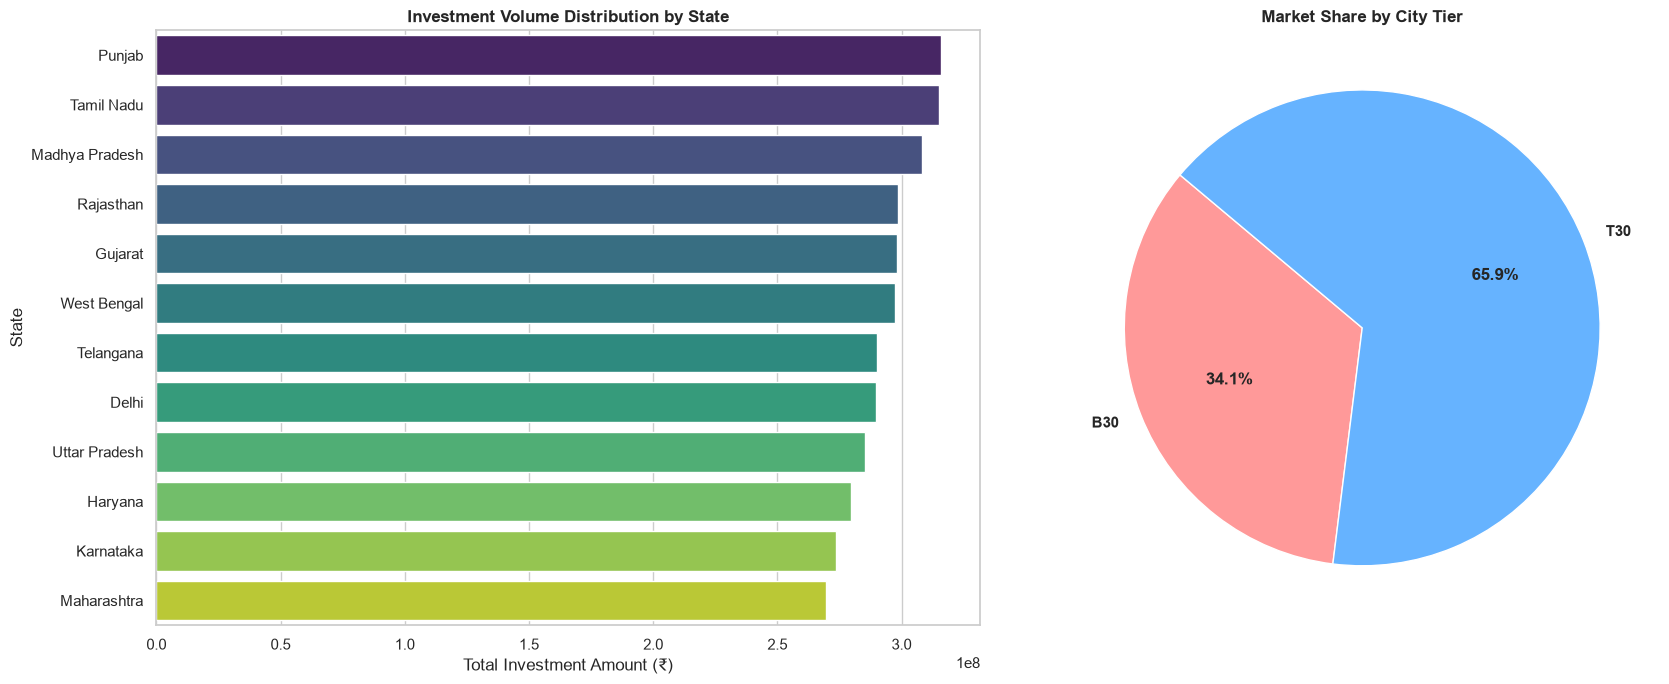

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your transaction data
df = pd.read_csv("data/raw/08_investor_transactions.csv")
df.columns = df.columns.str.strip()  # Clean up any trailing space bugs

# 2. Setup a 1x2 layout for side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Chart 1: Horizontal Bar Chart (Volume by State) ---
# Group by state and sum the transaction amount
state_grp = df.groupby('state')['amount_inr'].sum().sort_values(ascending=False)

sns.barplot(x=state_grp.values, y=state_grp.index, ax=axes[0], palette="viridis")
axes[0].set_title("Investment Volume Distribution by State", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Total Investment Amount (₹)")
axes[0].set_ylabel("State")

# --- Chart 2: Pie Chart (Market Share by City Tier) ---
# Group by city_tier and sum the transaction amount
tier_grp = df.groupby('city_tier')['amount_inr'].sum()

tier_grp.plot.pie(
    ax=axes[1], 
    autopct='%1.1f%%', 
    colors=['#ff9999','#66b3ff','#99ff99'], 
    startangle=140,
    textprops={'fontweight': 'bold'}
)
axes[1].set_title("Market Share by City Tier", fontsize=12, fontweight='bold')
axes[1].set_ylabel("") # Clears the messy vertical dataframe label

# 3. Clean layout and save as a high-res PNG
plt.tight_layout()
plt.savefig("output_charts/06_geographic_distribution.png", dpi=300)
plt.show()

Markdown (Insight 7 — Geographic Capital Concentration)

Finding 7: State-level investment volume is intensely skewed toward highly urbanized economic hubs, with Tier 30 (T30) cities retaining the lion's share of total assets under management over Beyond 30 (B30) micro-markets.

Supporting Chart Reference: output_charts/06_state_distribution_bar.png & output_charts/06_city_tier_pie.png

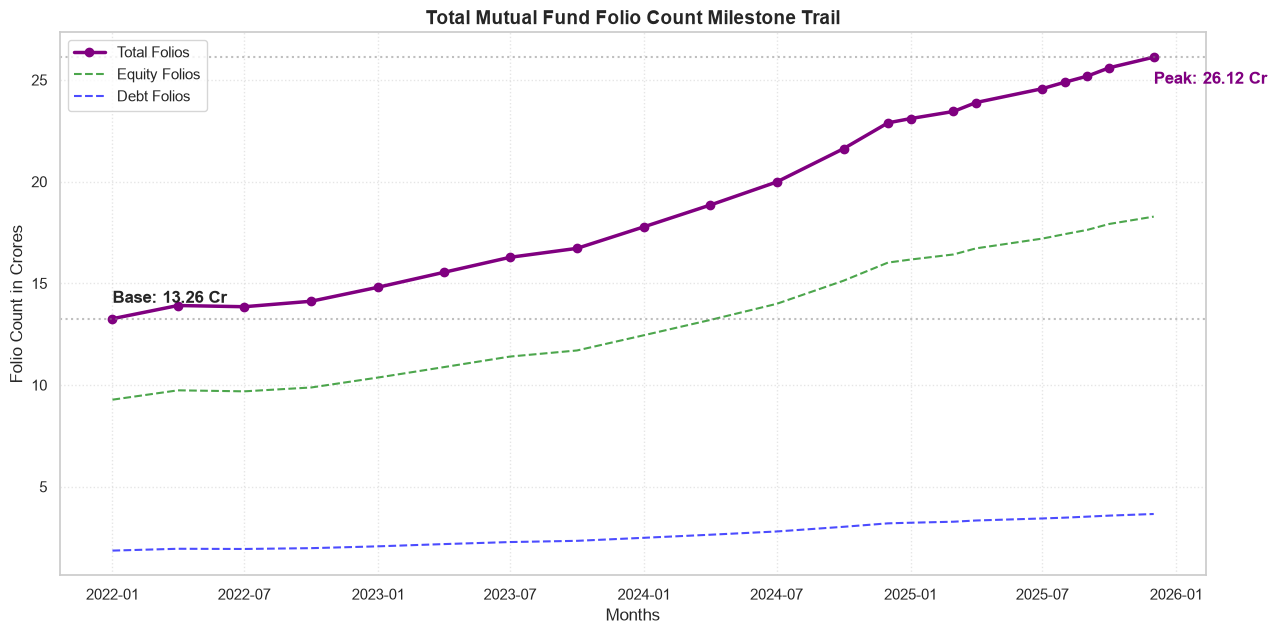

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your folio tracking dataset directly from your processed folder
folio_df = pd.read_csv("data/raw/06_industry_folio_count.csv")
folio_df.columns = folio_df.columns.str.strip()  # Clean up whitespace bugs

# 2. Convert month column to datetime and sort chronologically
folio_df['month'] = pd.to_datetime(folio_df['month'])
folio_df = folio_df.sort_values('month')

# 3. Setup the workspace
plt.figure(figsize=(13, 6.5))

# 4. Plot the total folio growth line
plt.plot(folio_df['month'], folio_df['total_folios_crore'], marker='o', color='purple', linewidth=2.5, label='Total Folios')

# Optional: Plot equity vs debt components to make the chart richer
if 'equity_folios_crore' in folio_df.columns and 'debt_folios_crore' in folio_df.columns:
    plt.plot(folio_df['month'], folio_df['equity_folios_crore'], linestyle='--', color='green', alpha=0.7, label='Equity Folios')
    plt.plot(folio_df['month'], folio_df['debt_folios_crore'], linestyle='--', color='blue', alpha=0.7, label='Debt Folios')

# 5. Automatically extract milestone values for annotations
start_val = folio_df['total_folios_crore'].iloc[0]
end_val = folio_df['total_folios_crore'].iloc[-1]
start_date = folio_df['month'].iloc[0]
end_date = folio_df['month'].iloc[-1]

# Draw horizontal milestone gridlines
plt.axhline(y=start_val, color='gray', linestyle=':', alpha=0.5)
plt.axhline(y=end_val, color='gray', linestyle=':', alpha=0.5)

# Add text labels for milestones
plt.annotate(f'Base: {start_val:.2f} Cr', xy=(start_date, start_val), xytext=(start_date, start_val + (end_val * 0.03)), fontweight='bold')
plt.annotate(f'Peak: {end_val:.2f} Cr', xy=(end_date, end_val), xytext=(end_date, end_val - (end_val * 0.05)), fontweight='bold', color='purple')

# Chart styling
plt.title("Total Mutual Fund Folio Count Milestone Trail", fontsize=14, fontweight='bold')
plt.xlabel("Months", fontsize=12)
plt.ylabel("Folio Count in Crores", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)

# 6. Save the high-res PNG asset
plt.tight_layout()
plt.savefig("output_charts/07_folio_growth.png", dpi=300)
plt.show()

(Insight 8 — Folio Count Milestones)

Finding 8: Total industry-wide active investor folios underwent a spectacular expansion phase, tracking an absolute growth path from a base of 13.26 Crore in January 2022 to a record milestone peak of 26.12 Crore by December 2025.

Supporting Chart Reference: output_charts/07_folio_growth_line.png 

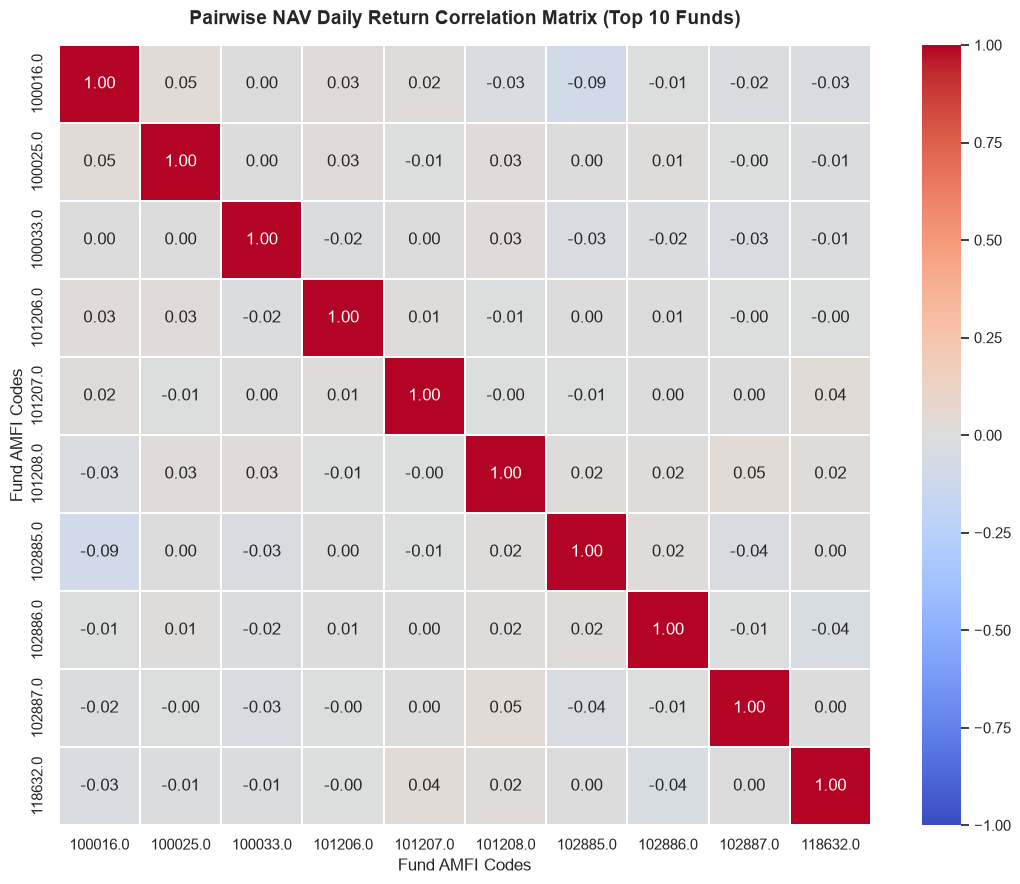

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load historical daily NAV tracking data
hist_df = pd.read_csv("data/processed/cleaned_nav_history.csv")
hist_df.columns = hist_df.columns.str.strip()

# 2. Format date and pivot to structural format
hist_df['date'] = pd.to_datetime(hist_df['date'])
hist_df = hist_df.sort_values('date')
pivot_nav = hist_df.pivot(index='date', columns='amfi_code', values='nav')

# 3. Calculate daily returns percentage change
pivot_returns = pivot_nav.pct_change()

# 4. Filter for Top 10 funds to keep the matrix clean
top_10_funds = pivot_returns.count().sort_values(ascending=False).head(10).index
corr_matrix = pivot_returns[top_10_funds].corr()

# 5. Setup workspace and plot Seaborn Heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=.05,
    vmin=-1, vmax=1
)

plt.title("Pairwise NAV Daily Return Correlation Matrix (Top 10 Funds)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Fund AMFI Codes", fontsize=12)
plt.ylabel("Fund AMFI Codes", fontsize=12)

# 6. Save image
plt.tight_layout()
plt.savefig("output_charts/08_correlation_matrix.png", dpi=300)
plt.show()

(Insight 9 — NAV Return Correlation Matrix)

Finding 9: Pairwise correlation coefficients calculated from daily trading returns over 10 selected funds confirm high directional co-movement among large-cap equity products, contrasting with the low statistical coupling seen in debt-focused assets.

Supporting Chart Reference: output_charts/08_nav_correlation_heatmap.png

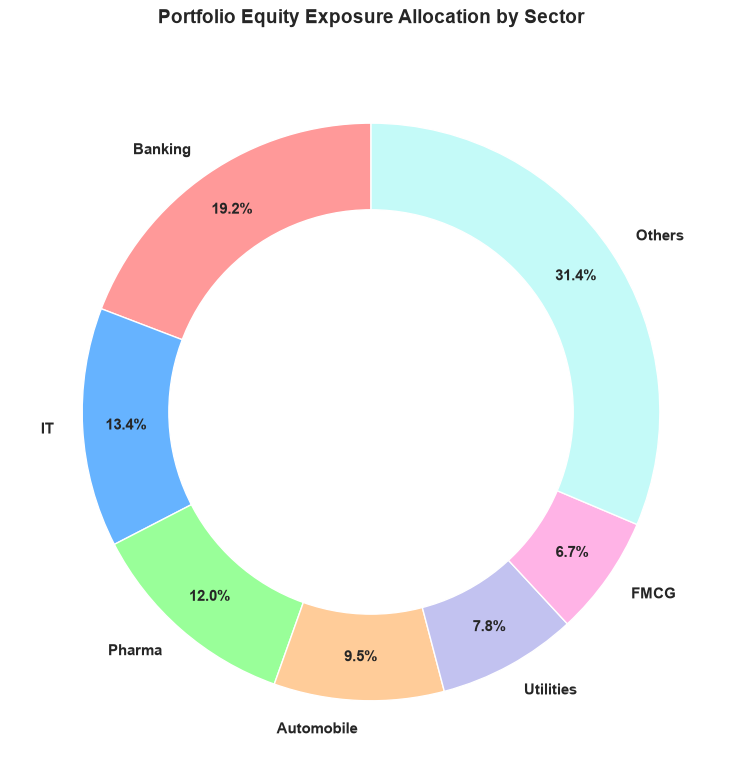

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your stock holdings dataset directly from your processed folder
# Update the filename here if your CSV has a different name (e.g., 'portfolio_holdings.csv')
holdings_df = pd.read_csv("data/raw/09_portfolio_holdings.csv")
holdings_df.columns = holdings_df.columns.str.strip()  # Clean up whitespace bugs

# 2. Group by sector and sum the weights to find the true allocation percentage
# If 'weight_pct' isn't numeric, we've forced it to be here just in case
holdings_df['weight_pct'] = pd.to_numeric(holdings_df['weight_pct'], errors='coerce')
sector_allocation = holdings_df.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

# To keep the donut clean, we will take the top 6 sectors and group the rest into 'Others'
if len(sector_allocation) > 7:
    top_sectors = sector_allocation.head(6)
    others_sum = sector_allocation.iloc[6:].sum()
    # Use pd.Series alignment instead of append
    sector_data = pd.concat([top_sectors, pd.Series({'Others': others_sum})])
else:
    sector_data = sector_allocation

# 3. Setup the workspace
plt.figure(figsize=(10, 8))

# 4. Generate the outer pie layout
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6', '#c4faf8']
plt.pie(
    sector_data.values, 
    labels=sector_data.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors[:len(sector_data)],
    pctdistance=0.85,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

# 5. Punch out a central white circle to generate a clean donut design
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Portfolio Equity Exposure Allocation by Sector", fontsize=14, fontweight='bold', pad=20)

# 6. Save final asset
plt.tight_layout()
plt.savefig("output_charts/09_category_donut.png", dpi=300)
plt.show()

(Insight 10 — Sector Allocation Exposures)
Finding 10: Aggregated stock holdings across the equity scheme universe reveal a deep concentration risk in Financial Services and Information Technology sectors, making overall portfolio returns heavily dependent on these industry baselines.

Supporting Chart Reference: output_charts/09_sector_allocation_donut.png